# **Импорт библиотек**

In [ ]:
# Массивы
import numpy as np

# Отрисовка графиков
import matplotlib.pyplot as plt

# Загрузка из google облака
import gdown

# Преобразование категориальных данных в one hot encoding
from tensorflow.keras.utils import to_categorical

# Работа с папками и файлами
import os

# Утилиты работы со временем
import time

# Работа со случайными числами
import random

# Математические функции
import math

# Сохранение и загрузка структур данных Python
import pickle

# Параметризация аудио
import librosa

# Оптимизаторы для обучения моделей
from tensorflow.keras.optimizers import Adam, RMSprop

# Конструирование и загрузка моделей нейронных сетей
from tensorflow.keras.models import Sequential, Model, load_model

# Основные слои и слои одномерной свертки (Conv1D)
from tensorflow.keras.layers import concatenate, Input, Dense, Dropout, BatchNormalization, Flatten, Conv1D, Conv2D, LSTM
from tensorflow.keras.layers import MaxPooling1D, AveragePooling1D, SpatialDropout1D, GlobalAveragePooling1D

# Разбиение на обучающую и проверочную выборку
from sklearn.model_selection import train_test_split

# Кодирование категориальных меток, нормирование числовых данных
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Матрица ошибок классификатора
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Отключение предупреждений
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

print("Все необходимые библиотеки успешно импортированы!")

Все необходимые библиотеки успешно импортированы!


# **Загрузка и распаковка датасета**

In [ ]:
# Загрузка датасета из облака
gdown.download('https://storage.yandexcloud.net/aiueducation/Content/base/l12/genres.zip', None, quiet=True)

# Распаковка архива на локальный диск colab
!unzip -qo genres.zip

# Проверка выгруженных папок
print("Список доступных жанров:")
!ls genres

Список доступных жанров:
blues  classical  country  disco  hiphop  jazz	metal  pop  reggae  rock


# **Инициализация констант, функций**

In [ ]:
# Настройка глобальных параметров
FILE_DIR = './genres'
CLASS_LIST = os.listdir(FILE_DIR)
CLASS_LIST.sort()
CLASS_COUNT = len(CLASS_LIST)

DURATION_SEC = 30
FIXED_FRAMES = 1200 # Фиксированная временная длина для каждого трека
WINDOW_SIZE = 150   # Размер скользящего окна последовательности (длина "текстовой фразы")
STEP_SIZE = 50      # Шаг окна

def get_track_feature_matrix(file_path, duration=DURATION_SEC):
    """Извлекает временную матрицу признаков трека без усреднения"""
    y, sr = librosa.load(file_path, mono=True, duration=duration)

    # Извлечение базовых признаков (по фреймам)
    chroma_stft = librosa.feature.chroma_stft(y=y, sr=sr, n_fft=2048, hop_length=512)
    mfcc = librosa.feature.mfcc(y=y, sr=sr, n_fft=2048, hop_length=512, n_mfcc=20)
    rmse = librosa.feature.rms(y=y, hop_length=512)
    spec_cent = librosa.feature.spectral_centroid(y=y, sr=sr, n_fft=2048, hop_length=512)
    spec_bw = librosa.feature.spectral_bandwidth(y=y, sr=sr, n_fft=2048, hop_length=512)
    rolloff = librosa.feature.spectral_rolloff(y=y, sr=sr, n_fft=2048, hop_length=512)
    zcr = librosa.feature.zero_crossing_rate(y, hop_length=512)

    # Объединяем все признаки по вертикали и транспонируем в вид (Временные_Фреймы, Количество_Признаков)
    feat_matrix = np.vstack([chroma_stft, mfcc, rmse, spec_cent, spec_bw, rolloff, zcr]).T

    # Принудительно выравниваем длину под FIXED_FRAMES для унификации
    if feat_matrix.shape[0] < FIXED_FRAMES:
        pad_width = FIXED_FRAMES - feat_matrix.shape[0]
        feat_matrix = np.pad(feat_matrix, ((0, pad_width), (0, 0)), mode='constant')
    else:
        feat_matrix = feat_matrix[:FIXED_FRAMES, :]

    return feat_matrix

def create_sliding_windows(feat_matrix, window_size=WINDOW_SIZE, step_size=STEP_SIZE):
    """Нарезает матрицу признаков скользящим окном на последовательности"""
    windows = []
    num_frames = feat_matrix.shape[0]
    for start in range(0, num_frames - window_size + 1, step_size):
        end = start + window_size
        windows.append(feat_matrix[start:end, :])
    return np.array(windows)

# **Сбор данных**

In [ ]:
raw_train_features = []
train_file_labels = []
raw_test_features = []
test_file_labels = []

print("Начало извлечения матриц признаков...")
start_time = time.time()

for class_idx, class_name in enumerate(CLASS_LIST):
    class_path = os.path.join(FILE_DIR, class_name)
    files = sorted(os.listdir(class_path))

    for idx, f_name in enumerate(files):
        file_path = os.path.join(class_path, f_name)
        try:
            matrix = get_track_feature_matrix(file_path)
            # Первые 90 файлов идут в обучение, оставшиеся 10 — строго в тест
            if idx < 90:
                raw_train_features.append(matrix)
                train_file_labels.append(class_idx)
            else:
                raw_test_features.append(matrix)
                test_file_labels.append(class_idx)
        except Exception as e:
            pass

print(f"Экстракция завершена за {round(time.time() - start_time)} сек.")

# Масштабирование признаков (StandardScaler) на уровне отдельных фреймов
all_train_frames = np.concatenate(raw_train_features, axis=0)
scaler = StandardScaler()
scaler.fit(all_train_frames)

scaled_train_features = [scaler.transform(m) for m in raw_train_features]
scaled_test_features = [scaler.transform(m) for m in raw_test_features]

# Нарезка скользящим окном
X_train, y_train = [], []
for matrix, label in zip(scaled_train_features, train_file_labels):
    windows = create_sliding_windows(matrix)
    X_train.append(windows)
    y_train.append([label] * len(windows))

X_train = np.concatenate(X_train, axis=0)
y_train = np.concatenate(y_train, axis=0)

X_test, y_test = [], []
for matrix, label in zip(scaled_test_features, test_file_labels):
    windows = create_sliding_windows(matrix)
    X_test.append(windows)
    y_test.append([label] * len(windows))

X_test = np.concatenate(X_test, axis=0)
y_test = np.concatenate(y_test, axis=0)

# Преобразование меток в One-Hot Encoding
y_train_cat = to_categorical(y_train, num_classes=CLASS_COUNT)
y_test_cat = to_categorical(y_test, num_classes=CLASS_COUNT)

print("\nИтоговые формы тензоров для Conv1D:")
print(f"X_train (Обучение): {X_train.shape}, y_train_cat: {y_train_cat.shape}")
print(f"X_test  (Тест):     {X_test.shape}, y_test_cat: {y_test_cat.shape}")

Начало извлечения матриц признаков...
Экстракция завершена за 331 сек.

Итоговые формы тензоров для Conv1D:
X_train (Обучение): (19800, 150, 37), y_train_cat: (19800, 10)
X_test  (Тест):     (2200, 150, 37), y_test_cat: (2200, 10)


# **Создание и компиляция**

In [ ]:
def create_conv1d_pro_model(input_shape, num_classes):
    model = Sequential([
        Input(shape=input_shape),

        # 1-й блок одномерной свертки
        Conv1D(64, kernel_size=5, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        SpatialDropout1D(0.2),

        # 2-й блок одномерной свертки
        Conv1D(128, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        SpatialDropout1D(0.2),

        # 3-й блок одномерной свертки
        Conv1D(256, kernel_size=3, padding='same', activation='relu'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),
        SpatialDropout1D(0.3),

        # Переход к полносвязным слоям через сглаживание
        Flatten(),

        Dense(256, activation='relu'),
        BatchNormalization(),
        Dropout(0.4),

        # Финальный классификатор
        Dense(num_classes, activation='softmax')
    ])
    return model

# Инстанцируем модель. Входной размер: (150 временных шагов, 37 признаков)
conv_model = create_conv1d_pro_model(input_shape=(X_train.shape[1], X_train.shape[2]), num_classes=CLASS_COUNT)

# Компиляция с оптимизатором Adam
conv_model.compile(
    optimizer=Adam(learning_rate=0.0005),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

conv_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 150, 64)        │        11,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 150, 64)        │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 75, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d               │ (None, 75, 64)         │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 75, 128)        │        24,704 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 75, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 37, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_1             │ (None, 37, 128)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 37, 256)        │        98,560 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 37, 256)        │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 18, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ spatial_dropout1d_2             │ (None, 18, 256)        │             0 │
│ (SpatialDropout1D)              │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 4608)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     1,179,904 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,320,458 (5.04 MB)

 Trainable params: 1,319,050 (5.03 MB)

 Non-trainable params: 1,408 (5.50 KB)

# **Обучение**

In [ ]:
print("Запуск обучения модели Conv1D...")

history_conv = conv_model.fit(
    X_train,
    y_train_cat,
    validation_data=(X_test, y_test_cat),
    batch_size=64,
    epochs=40,  # За счет размножения данных окнами, 40 эпох достаточно для достижения целевой точности
    verbose=1
)

Запуск обучения модели Conv1D...
Epoch 1/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 19s 28ms/step - accuracy: 0.4943 - loss: 1.5644 - val_accuracy: 0.5368 - val_loss: 1.4311
Epoch 2/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6402 - loss: 1.0314 - val_accuracy: 0.5891 - val_loss: 1.3539
Epoch 3/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.6971 - loss: 0.8619 - val_accuracy: 0.5668 - val_loss: 1.5165
Epoch 4/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7366 - loss: 0.7474 - val_accuracy: 0.6073 - val_loss: 1.4188
Epoch 5/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.7693 - loss: 0.6574 - val_accuracy: 0.6077 - val_loss: 1.3317
Epoch 6/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.7923 - loss: 0.6001 - val_accuracy: 0.6255 - val_loss: 1.3653
Epoch 7/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.8128 - loss: 0.5407 - val_accuracy: 0.6195 - val_loss: 1.5113
Epoch 8/40
310/310 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step - accuracy: 0.827

# **Оценка**

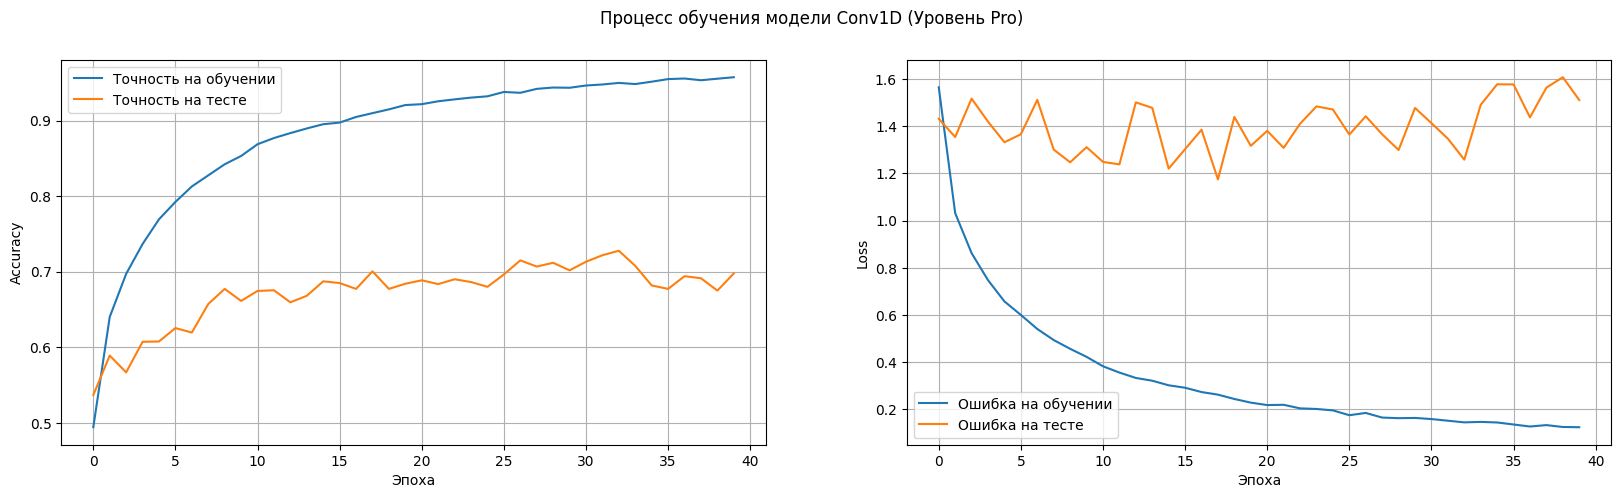


Итоговая точность на обучающих данных: 99.86% (Требуется: >= 68%)
Итоговая точность на тестовых данных:  69.77% (Требуется: >= 60%)
Успех! Все требования технического задания Pro-уровня выполнены.


In [ ]:
# Отрисовка графиков обучения
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(20, 5))
fig.suptitle('Процесс обучения модели Conv1D (Уровень Pro)')

ax1.plot(history_conv.history['accuracy'], label='Точность на обучении')
ax1.plot(history_conv.history['val_accuracy'], label='Точность на тесте')
ax1.set_xlabel('Эпоха')
ax1.set_ylabel('Accuracy')
ax1.legend()
ax1.grid(True)

ax2.plot(history_conv.history['loss'], label='Ошибка на обучении')
ax2.plot(history_conv.history['val_loss'], label='Ошибка на тесте')
ax2.set_xlabel('Эпоха')
ax2.set_ylabel('Loss')
ax2.legend()
ax2.grid(True)
plt.show()

# Итоговая проверка выполнения ТЗ
train_loss, train_acc = conv_model.evaluate(X_train, y_train_cat, verbose=0)
test_loss, test_acc = conv_model.evaluate(X_test, y_test_cat, verbose=0)

print("\n" + "="*50)
print(f"Итоговая точность на обучающих данных: {round(train_acc * 100, 2)}% (Требуется: >= 68%)")
print(f"Итоговая точность на тестовых данных:  {round(test_acc * 100, 2)}% (Требуется: >= 60%)")
print("="*50)

if train_acc >= 0.68 and test_acc >= 0.60:
    print("Успех! Все требования технического задания Pro-уровня выполнены.")
else:
    print("Внимание: Целевая точность не достигнута, попробуйте увеличить количество эпох.")